### Initialize instrumentation

In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
# set up readout and plotting
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
# open list of available instruments
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL11::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
# connect to BNC 575 pulse generator (for controlling experimental time sequence)
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [5]:
# connect to SR400 gated photon counter (for performing Rydberg atom counting)
sr400 = SR400.SR400("GPIB0::23::INSTR", timeout = 5000)

In [6]:
# connect to WeederTech WTMCD-M driver (for 480 stepper motor)
weeder = Weeder.Weeder("ASRL1::INSTR")

In [7]:
# connect to MC USB-3114 (for compensation voltages)
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


### Define the pulse sequence

#### Sequence 1: MOT always ON

In [ ]:
pulse_arrangement = [         
                     ["C", 15, 0, "TTL"],            # 480 EXC,
                    ]
T = 15.01

In [ ]:
bnc575.clock_set(period = T, mode = "CONTINUOUS")
bnc575.pulse_sequence_setup(pulse_arrangement)

In [ ]:
bnc575.start_pulses()

#### Sequence 2: Normal timing

In [8]:
# full sequence
# pulse_arrangement = [["A", 900e-6, 0, "TTL"],              # MOT
#                      [["B", 10e-6, 5e-6, 15],              # 780 EXC (20dB attenuator connected)
#                       ["C", 10e-6, 5e-6, "TTL"]],          # 480 EXC
#                      ["E", 25e-6, 0, 8],                   # DEI switch
#                     ]

# partial sequence with blue excitation light only
pulse_arrangement = [["A", 900e-6, 0, "TTL"],              # MOT
                     ["C", 10e-6, 5e-6, "TTL"],            # 480 EXC
                     ["E", 30e-6, 0, 8],                   # DEI switch/photon counter
                    ]

# pulse_arrangement = [
#                      ["D", 20e-6, 0, 8],                   # DEI switch
#                     ]
T = 1100e-6

cycle_number = 30

# photon counter gate width and delay
gate_width = 20e-6
gate_delay = 3e-6

# stepper motor slope (for blue laser)
freq_factor = 129 * 2 # kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [9]:
# set up the photon counter
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num = cycle_number, 
                  dwell = 0, sourceA = "INPUT1", sourceB = "INPUT2", gate_A_mode = "FIXED",
                  gate_A_delay = gate_delay, gate_A_width = gate_width, gate_B_mode = "CW")

------------------------------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 20.00E-6


The gate B is set to: CW
------------------------------------------------------------


In [10]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.10e-03s
Pulses number: N/A
------------------------------------------------------------
[['A', 0.0009, 0, 'TTL'], ['C', 1e-05, 0.000905, 'TTL'], ['E', 3e-05, 0.000915, 8]]
------------------------------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
------------------------------------------------------------
------------------------------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
------------------------------------------------------------
------------------------------------------------------------
The channel E is set to:
Width: 3.0000e-05s
Delay: 9.1500e-04s
Synchronize to: T0
Out: 8.00

Output timers:
HGFEDCBA
00010000
-------------------------------------

In [11]:
bnc575.start_pulses()

### Initial search for a Rydberg resonance

In [39]:
# find current stepper motor position
weeder.position(header = "A", query = True)

'A7950'

In [17]:
# begin stepper motor at initial position 6000, then move it out to increase the laser frequency
weeder.move("A", position = 7650, progress = True)

start at 7600 --> 7650.0 --> 7650
Old position: 7600
New position: 7650


In [ ]:
# used to move motor incrementally to zero in on the location of a resonance
weeder.advance(header = "A", num_step = -10)

### Stark map generation

#### 1D map (varying frequency only)

In [36]:
center = 7650
stride = 2
half_width = 300

# scan list gneration
x_list = np.arange(2* half_width/stride)

In [37]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

results = []
s = time.perf_counter()
for idx in x_list:
    print(f"Now checking step: {idx}", end = "\r", flush = True)
    sr400.count_reset()
    result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A", "+")
    time.sleep(0.1)
    
e = time.perf_counter()
print('Time elapsed: {} seconds'.format(e-s))

start at 7850 --> 7250.0 --> 7250
Old position: 7850
New position: 7250
start at 7250 --> 7350.0 --> 7350
Old position: 7250
New position: 7350
Time elapsed: 71.09751239999605 seconds


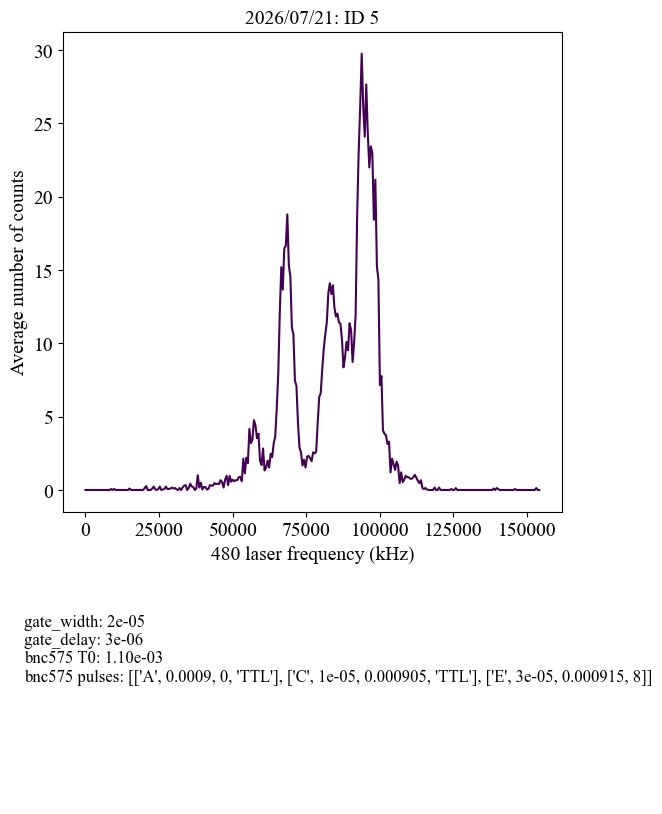

In [38]:
# plot results
ps.Plot2D(x = x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

#### 2D map (varying both electrode voltage and laser frequency; narrow voltage scan)

In [34]:
center = center
stride = 1
half_width = 200

# scan list gneration
s_list = np.arange(2* half_width/stride)

# list of voltage setpoints
#vset = np.array([0.2,-0.1,0.6])
#vset_init = np.array([0.0,0.0,0.0])
vset = np.array([0.1,-0.1,0.25])

num_voltages = 11

vx_list = np.linspace(-0.5,0.8,num_voltages) + vset[0]
vy_list = np.linspace(-0.5,0.8,num_voltages) + vset[1]
vz_list = np.linspace(-0.5,0.8,num_voltages) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

electrode_pair = [[10,11],[6,7],[0,1]]

In [35]:
mcbox.set_voltage_1chan(channel = 10, voltage = vset[0], bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 11, voltage = -vset[0], bipolar = True, display = True)

mcbox.set_voltage_1chan(channel = 6, voltage = vset[1], bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 7, voltage = -vset[1], bipolar = True, display = True)

mcbox.set_voltage_1chan(channel = 0, voltage = 0, bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 1, voltage = -vset[2], bipolar = True, display = True)

Channel 10 has been set to 0.1 V.
Channel 11 has been set to -0.1 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 0 has been set to 0 V.
Channel 1 has been set to -0.25 V.


In [32]:
start_position = center - half_width

stark_map = []

# choose axis: x = 0, y = 1, z = 2
i = 2

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)
s = time.perf_counter()
for s in s_list:
    for j in range(stride):
            weeder.step("A", "+")
    print(f"Now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(channel = electrode_pair[i][0], voltage = 0, bipolar = True, display = False)
        else:
            mcbox.set_voltage_1chan(channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display = False)
        mcbox.set_voltage_1chan(channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display = False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
        results.append(result)
        
    stark_map.append(results)

e = time.perf_counter()
print('Time elapsed: {} seconds'.format(e-s))

Now checking axis 2
start at 7850 --> 7350.0 --> 7350
Old position: 7850
New position: 7350
start at 7350 --> 7450.0 --> 7450
Old position: 7350
New position: 7450
Time elapsed: 82789.2173761 seconds


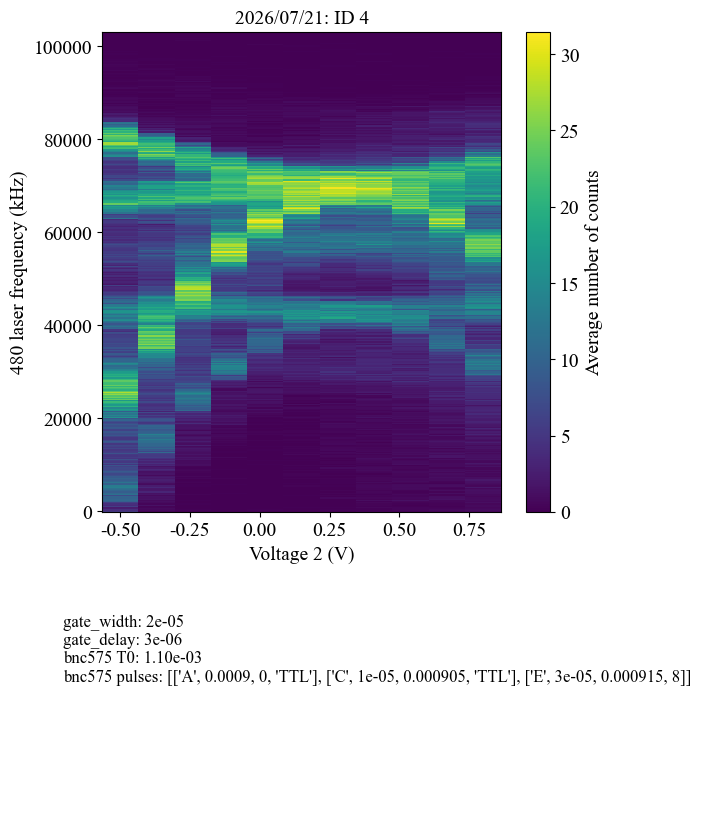

In [33]:
ps.Plot3D(x = v_list[i], y = s_list*stride*freq_factor, Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

#### Peak finding and curve fitting (use for estimating zeroing voltages; needs to be optimized but is OK)

In [ ]:
peaks_x = []
peaks_y = []
peaks_list = []

for k in range(len(stark_map[0])):
    freq_scan = np.array(stark_map)[:,k]
    peaks,_ = find_peaks(freq_scan, height = 15, distance = 50)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(v_list[i][k])
            peaks_y.append((s_list*stride*freq_factor)[p])
        peaks_list.append(peaks)

peaks_list = np.array(peaks_list)
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T

In [ ]:
plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
ssum = 0 

for l in range(3):
    a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
    plt.scatter(peaks_x[l],peaks_y[l])
    plt.plot(v_list[i], a * v_list[i]**2 + b * v_list[i] +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    plt.xlabel(f"Voltage {i} (V)")
    plt.ylabel("Frequency (kHz)")
    ssum += -b/(2*a)

print(ssum/3)
plt.colorbar()

#### 2D map (varying both electrode voltage and laser frequency; wide voltage scan)

In [ ]:
center = center  # center point of frequency scan
stride = 2  # step size
half_width = 300  # step range

# scan list gneration
s_list = np.arange(2*half_width/stride)

# voltage setpoints
#vset = np.array([0.2,-0.2,0.4])
vset_init = np.array([0.0,0.0,0.0])
vset = vset_init

num_voltages = 31  # number of voltages to test

# voltage arrays for each axis
vx_list = np.linspace(-2.0,2.0,num_voltages) + vset[0]
vy_list = np.linspace(-2.0,2.0,num_voltages) + vset[1]
vz_list = np.linspace(-2.0,2.0,num_voltages) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

# MC channels for each electrode pair
electrode_pair = [[10,11],[6,7],[0,1]]

In [ ]:
# initialize electrode voltages
mcbox.set_voltage_1chan(channel = 10, voltage = vset[0], bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 11, voltage = -vset[0], bipolar = True, display = True)

mcbox.set_voltage_1chan(channel = 6, voltage = vset[1], bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 7, voltage = -vset[1], bipolar = True, display = True)

mcbox.set_voltage_1chan(channel = 0, voltage = 0, bipolar = True, display = True)
mcbox.set_voltage_1chan(channel = 1, voltage = -vset[2], bipolar = True, display = True)

In [ ]:
# voltage scan inside a frequency scan
start_position = center - half_width

stark_map = []

# electrode pair to check; i = 0,1,2 for x,y,z
i = 0

test_voltages = generate_test_voltages(v_list[i])
print('Voltages to test: \n {}'.format(test_voltages))

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

#s = time.perf_counter()
#print('start:',s)

for s in s_list:
    for j in range(stride):
            weeder.step("A", "+")
    print(f"Now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in test_voltages:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(channel = electrode_pair[i][0], voltage = 0, bipolar = True, display = False)
        else:
            mcbox.set_voltage_1chan(channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display = False)
        mcbox.set_voltage_1chan(channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display = False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
        results.append(result)
    
    stark_map.append(results)

# e = time.perf_counter()
# print('end:',e)
# print('Time elapsed: {} seconds'.format(e-s))

In [ ]:
# plot results
ps.Plot3D(x = test_voltages, y = s_list*stride*freq_factor, Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

### Shutting down instrumentation

In [40]:
# reset voltages to setpoint values
mcbox.set_voltage_Nchan(channels = [0,1,6,7,10,11], voltages = [0,-vset[2],vset[1],-vset[1],vset[0],-vset[0]], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to -0.25 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 10 has been set to 0.1 V.
Channel 11 has been set to -0.1 V.
Voltages successfully set.


In [41]:
# save current stepper motor position
weeder.save(header = "A", query = True)

'saving complete.'

In [42]:
# OPTIONAL: disables pulses from BNC box (can also be done by pressing RUN/STOP button or individual channel buttons on device)
bnc575.disable_all()

In [43]:
# OPTIONAL: disarms the pulse generator (can also be done by pressing RUN/STOP button on device)
bnc575.disarm_all()

In [44]:
# OPTIONAL: used to reset photon counter (can also be done by pressing STOP button on device)
sr400.count_reset()

In [45]:
# disconnect from pulse generator
bnc575.pyvisa.close()

In [46]:
# disconnect from SRS photon counter
sr400.pyvisa.close()